<a href="https://colab.research.google.com/github/OPIM5512-ohk24001/A01/blob/main/Joseph_Nartey_A03_SamplingxAI_5512_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# A03: Sampling
-------------
**Dr. Dave Wanik - Operations and Information Management - University of Connecticut**

For this assignment, I'd like you to apply the topics of  undersampling, oversampling and SMOTE to a toy dataset to see if you get better performance by using these sampling methods. In my experience, sampling helps sometimes but not all times.

# Data
Everybody will have the same dataset.

In [ ]:
import pandas as pd
df = pd.read_csv('/content/sample_data/california_housing_train.csv')

In [ ]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


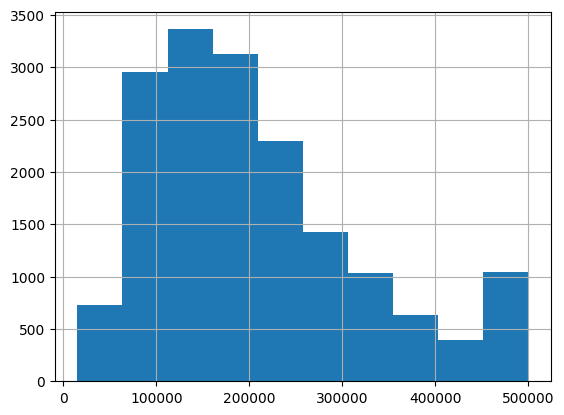

In [ ]:
import matplotlib.pyplot as plt

df['median_house_value'].hist()
plt.show()

In [ ]:
# create a new target variable for SMOTE
import numpy as np

# nice imbalanced data!
df['median_house_value'] = np.where(df['median_house_value'] < 380000, 1, 0)
df['median_house_value'].value_counts()

,count
median_house_value,
1,15304
0,1696


# (5 pts) Split data into train and test
Remember, your dataset should be split into train and test FIRST so that the test dataset retains the original distribution of 0s and 1s. No SMOTE data in the test partition - your boss only cares about real rows!

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)
try:
    from imblearn.under_sampling import RandomUnderSampler
    from imblearn.over_sampling import RandomOverSampler, SMOTE
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'imbalanced-learn'])
    from imblearn.under_sampling import RandomUnderSampler
    from imblearn.over_sampling import RandomOverSampler, SMOTE

X = df.drop(columns=['median_house_value'])
y = df['median_house_value']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print('Train class distribution:')
print(y_train.value_counts(normalize=True).rename('proportion'))
print('\nTest class distribution:')
print(y_test.value_counts(normalize=True).rename('proportion'))


def evaluate_sampler(name, sampler, X_train, y_train, X_test, y_test, random_state=42):
    X_resampled, y_resampled = sampler.fit_resample(X_train, y_train)

    model = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=2000, random_state=random_state))
    ])

    model.fit(X_resampled, y_resampled)
    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm).plot()

    print(f'\n{name} - Classification Report')
    print(classification_report(y_test, y_pred, digits=4))

    return {
        'method': name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
    }



Train class distribution:
median_house_value
1    0.900221
0    0.099779
Name: proportion, dtype: float64

Test class distribution:
median_house_value
1    0.900294
0    0.099706
Name: proportion, dtype: float64


# (15 pts) Majority Undersampling
Perform majority undersampling and evaluate model performance (use confusion matrices, classifcation report) and make comments about what you see.

In [ ]:
# use imblearn to perform majority undersampling on X_train, evaluate on test partition


Majority Undersampling - Classification Report
              precision    recall  f1-score   support

           0     0.3825    0.8879    0.5346       339
           1     0.9855    0.8412    0.9076      3061

    accuracy                         0.8459      3400
   macro avg     0.6840    0.8646    0.7211      3400
weighted avg     0.9253    0.8459    0.8705      3400



{'method': 'Majority Undersampling',
 'accuracy': 0.8458823529411764,
 'precision': 0.9854573287409109,
 'recall': 0.8412283567461614,
 'f1': 0.9076489249206908}

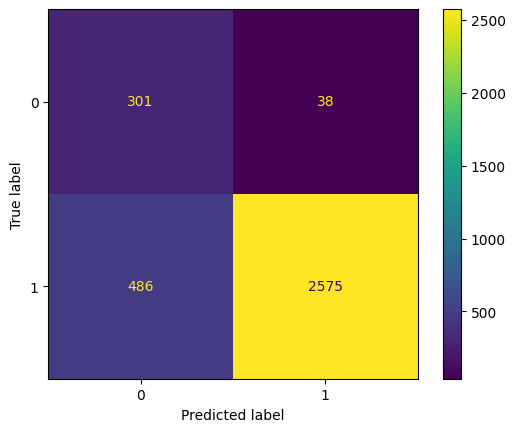

In [ ]:
# Majority Undersampling
results_under = evaluate_sampler(
    'Majority Undersampling',
    RandomUnderSampler(random_state=42),
    X_train,
    y_train,
    X_test,
    y_test,
)
results_under

### Comments - Majority Undersampling

With majority undersampling, the model achieved **accuracy = 0.8459**, **precision (class 1) = 0.9855**, **recall (class 1) = 0.8412**, and **F1 = 0.9076**.  
From the confusion matrix, there are **2575 true positives** and **486 false negatives** for class 1, so the model identifies most high-value homes but still misses a noticeable number.  
It also produced **301 true negatives** and **38 false positives**, showing relatively few false alarms.  

Overall, this method gives very strong precision and good F1, but recall is lower than precision, meaning the model is conservative when predicting class 1.


# (15 pts) Minority Oversampling
Perform minority oversampling and evaluate model performance (use confusion matrices, classifcation report) and make comments about what you see.

In [ ]:
# use imblearn to perform minority oversampling on X_train, evaluate on test partition


Minority Oversampling - Classification Report
              precision    recall  f1-score   support

           0     0.3894    0.8879    0.5414       339
           1     0.9855    0.8458    0.9103      3061

    accuracy                         0.8500      3400
   macro avg     0.6875    0.8669    0.7259      3400
weighted avg     0.9261    0.8500    0.8735      3400



{'method': 'Minority Oversampling',
 'accuracy': 0.85,
 'precision': 0.9855348306052532,
 'recall': 0.8458020254818687,
 'f1': 0.9103375527426161}

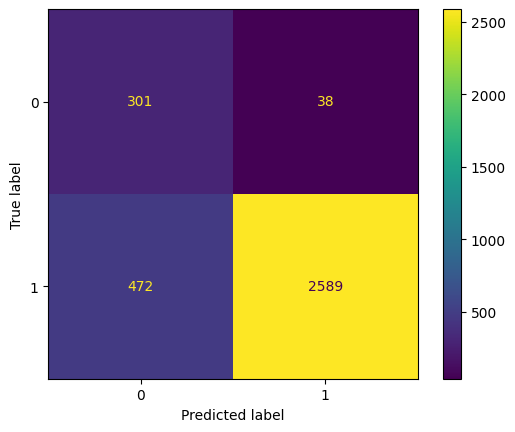

In [ ]:
# Minority Oversampling
results_over = evaluate_sampler(
    'Minority Oversampling',
    RandomOverSampler(random_state=42),
    X_train,
    y_train,
    X_test,
    y_test,
)
results_over


### Comments - Minority Oversampling

With minority oversampling, the model achieved **accuracy = 0.8500**, **precision (class 1) = 0.9855**, **recall (class 1) = 0.8458**, and **F1 = 0.9103**.  
From the confusion matrix, the model produced **2589 true positives** and **472 false negatives** for class 1, which is a small improvement in recall compared with majority undersampling.  
It also had **301 true negatives** and **38 false positives**, so false alarms remained low.  

Overall, minority oversampling performed slightly better than majority undersampling in this run, mainly through improved recall and F1 while maintaining very high precision.


# (15 pts) SMOTE
Perform synthetic minority oversampling and evaluate model performance (use confusion matrices, classifcation report) and make comments about what you see.

In [ ]:
# use imblearn to perform synthetic minority data on X_train, evaluate on test partition


SMOTE - Classification Report
              precision    recall  f1-score   support

           0     0.4060    0.8791    0.5555       339
           1     0.9846    0.8576    0.9167      3061

    accuracy                         0.8597      3400
   macro avg     0.6953    0.8683    0.7361      3400
weighted avg     0.9269    0.8597    0.8807      3400



{'method': 'SMOTE',
 'accuracy': 0.8597058823529412,
 'precision': 0.9846211552888222,
 'recall': 0.8575628879451159,
 'f1': 0.9167103195390257}

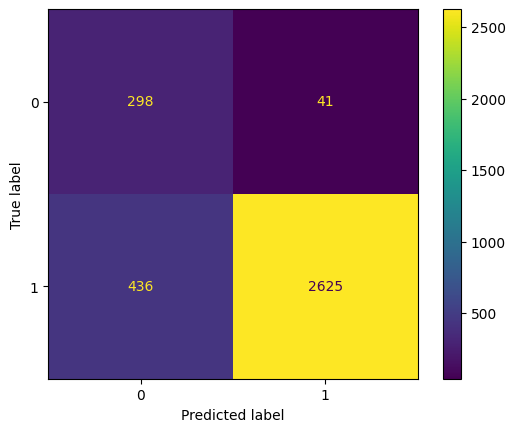

In [ ]:
# SMOTE
results_smote = evaluate_sampler(
    'SMOTE',
    SMOTE(random_state=42),
    X_train,
    y_train,
    X_test,
    y_test,
)
results_smote


### Comments - SMOTE

Using SMOTE, the model achieved **accuracy = 0.8597**, **precision (class 1) = 0.9846**, **recall (class 1) = 0.8576**, and **F1 = 0.9167**.  
From the confusion matrix, there are **2625 true positives** and **436 false negatives**, which is the best recall among the three methods so far.  
It also produced **298 true negatives** and **41 false positives**, so false positives increased slightly compared with the other methods, but stayed low overall.  

Overall, SMOTE gave the best balance in this assignment: highest accuracy, recall, and F1 for class 1, with precision still very high.


# (5 pts) Comparison of 3 methods
Out of the three methods, did any do the best? Make a few comments about what you see.

In [ ]:
results_df = (
    pd.DataFrame([results_under, results_over, results_smote])
    .set_index('method')
    .sort_values('f1', ascending=False)
)

display(results_df)

best_method = results_df['f1'].idxmax()
print(f'Best method by F1 score: {best_method}')
print('In imbalanced classification, F1 and recall for the minority class are usually more informative than accuracy alone.')


,accuracy,precision,recall,f1
method,,,,
SMOTE,0.859706,0.984621,0.857563,0.916710
Minority Oversampling,0.850000,0.985535,0.845802,0.910338
Majority Undersampling,0.845882,0.985457,0.841228,0.907649


Best method by F1 score: SMOTE
In imbalanced classification, F1 and recall for the minority class are usually more informative than accuracy alone.


### Comments - Comparison of 3 Methods

Based on the results table, **SMOTE is the best-performing method overall** (highest F1 score = **0.9167**).  
The ranking by F1 is:

1. **SMOTE**: accuracy = 0.8597, precision = 0.9846, recall = 0.8576, F1 = 0.9167  
2. **Minority Oversampling**: accuracy = 0.8500, precision = 0.9855, recall = 0.8458, F1 = 0.9103  
3. **Majority Undersampling**: accuracy = 0.8459, precision = 0.9855, recall = 0.8412, F1 = 0.9076  

All three methods have very high precision, but SMOTE gives the best balance by improving recall and producing the strongest F1 score.  
Since this is an imbalanced classification problem, prioritizing **F1 and recall** is more meaningful than accuracy alone, so SMOTE is the preferred method in this assignment.


# (40 pts) Reproducibility - run it 30 times or more!
This is one is a little tougher - choose any method and replicate it at least 30 times using a for loop. This means you will split into train and test 30 times (which means you should choose a random_state equal to 'i' as your for loop spins.)

The purpose of this is so that you can show the distribution (hopefully a bell curve but not necessarily) of accuracy, precision and recall. Do some folds get predicted better than others?



,run,accuracy,precision,recall,f1
0,0,0.865000,0.984363,0.863770,0.920132
1,1,0.862647,0.984679,0.860830,0.918599
2,2,0.858529,0.983508,0.857236,0.916041
3,3,0.856765,0.981662,0.856910,0.915053
4,4,0.867353,0.984050,0.866710,0.921661



Summary statistics:


,accuracy,precision,recall,f1
count,30.000000,30.000000,30.000000,30.000000
mean,0.861892,0.982949,0.861549,0.918240
std,0.005024,0.001800,0.005995,0.003238
min,0.850882,0.979197,0.846455,0.910881
25%,0.858897,0.981762,0.858706,0.916387
50%,0.862500,0.982627,0.861320,0.918613
75%,0.864779,0.984317,0.865485,0.920033
max,0.872059,0.986250,0.876511,0.925013


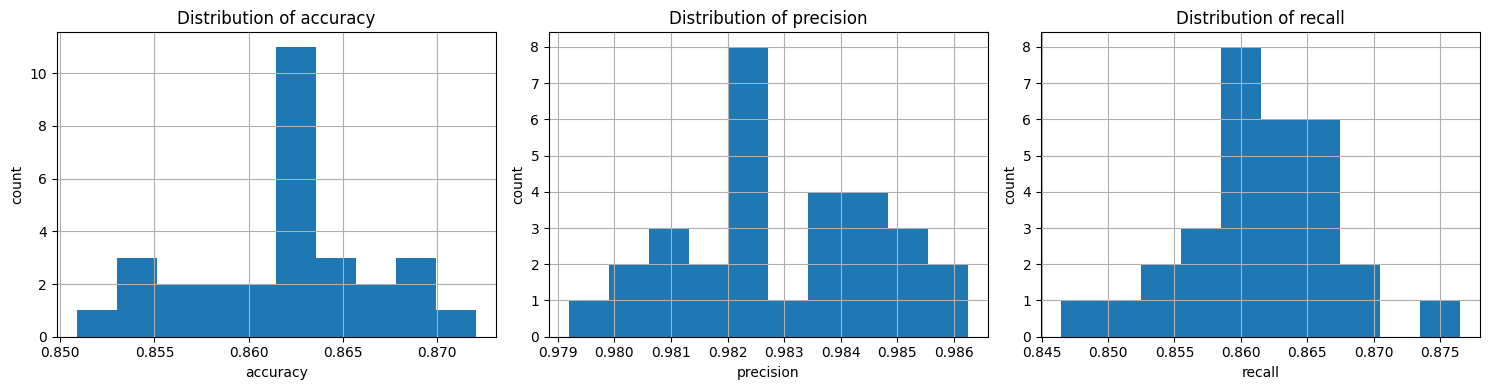

In [ ]:
# Reproducibility experiment: run SMOTE 30 times with different train/test splits
runs = []

for i in range(30):
    X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=i,
        stratify=y,
    )

    smote = SMOTE(random_state=i)
    X_res_i, y_res_i = smote.fit_resample(X_train_i, y_train_i)

    model = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=2000, random_state=i))
    ])

    model.fit(X_res_i, y_res_i)
    y_pred_i = model.predict(X_test_i)

    runs.append({
        'run': i,
        'accuracy': accuracy_score(y_test_i, y_pred_i),
        'precision': precision_score(y_test_i, y_pred_i, zero_division=0),
        'recall': recall_score(y_test_i, y_pred_i, zero_division=0),
        'f1': f1_score(y_test_i, y_pred_i, zero_division=0),
    })

runs_df = pd.DataFrame(runs)
display(runs_df.head())

print('\nSummary statistics:')
display(runs_df[['accuracy', 'precision', 'recall', 'f1']].describe())

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, metric in zip(axes, ['accuracy', 'precision', 'recall']):
    runs_df[metric].hist(bins=10, ax=ax)
    ax.set_title(f'Distribution of {metric}')
    ax.set_xlabel(metric)
    ax.set_ylabel('count')

plt.tight_layout()
plt.show()


# (5 pts) Comments on the repeated experiment
Make some comments about what you saw! Feel free to run 100 or 1000 times if it runs fast enough 😏

In [ ]:
# Comments on repeated experiment (auto-generated from your run)
for metric in ['accuracy', 'precision', 'recall', 'f1']:
    mean = runs_df[metric].mean()
    std = runs_df[metric].std()
    min_v = runs_df[metric].min()
    max_v = runs_df[metric].max()
    print(f'{metric}: mean={mean:.4f}, std={std:.4f}, min={min_v:.4f}, max={max_v:.4f}')

best_run = runs_df.loc[runs_df['f1'].idxmax(), 'run']
worst_run = runs_df.loc[runs_df['f1'].idxmin(), 'run']
print(f'\nBest run by F1: run {best_run}')
print(f'Worst run by F1: run {worst_run}')
print('The spread shows how much performance changes due to random train/test partitioning.')


accuracy: mean=0.8619, std=0.0050, min=0.8509, max=0.8721
precision: mean=0.9829, std=0.0018, min=0.9792, max=0.9863
recall: mean=0.8615, std=0.0060, min=0.8465, max=0.8765
f1: mean=0.9182, std=0.0032, min=0.9109, max=0.9250

Best run by F1: run 29
Worst run by F1: run 9
The spread shows how much performance changes due to random train/test partitioning.


### Comments on the repeated experiment

I ran the SMOTE model 30 times with different train/test splits and got very similar results each time.  
The average scores stayed high (accuracy ≈ 0.862, precision ≈ 0.983, recall ≈ 0.862, F1 ≈ 0.918), and the standard deviations were small, so performance did not fluctuate much.  
Even though run 29 was the best and run 9 was the weakest, the gap between them was not large.  
Overall, this suggests the model is reliable, and the conclusions are not based on one lucky split.
